In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Cell 1 — Imports

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tqdm import tqdm

Cell 2 — Paths

In [3]:
MEETIX_DATASET = "/kaggle/input/datasets/basilsaji03/phrase-ds-split-files/meetix_dataset"

LANDMARK_ROOT = "/kaggle/input/datasets/basilsaji03/zora-phrase-dataset/extracted_landmarks"

REPO_PATH = "/kaggle/input/datasets/basilsaji03/repo-files"

H2S_CKPT = "/kaggle/input/datasets/basilsaji03/unisign-dataset/how2sign_pose_only_slt.pth"

Cell 3 — Load Split

In [4]:
split = np.load(
    f"{MEETIX_DATASET}/full_train.npz",
    allow_pickle=True
)

print(split.files)

print(len(split["paths"]))
print(len(split["labels"]))

['paths', 'labels', 'phrases', 'signers']
292
292


In [5]:
with open(
    f"{MEETIX_DATASET}/phrase_map.json"
) as f:

    phrase_map = json.load(f)

id_to_phrase = {
    v:k
    for k,v in phrase_map.items()
}

print(id_to_phrase)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/basilsaji03/phrase-ds-split-files/meetix_dataset/phrase_map.json'

In [6]:
import json

with open(
    f"{MEETIX_DATASET}/vocab_info.json"
) as f:

    vocab_info = json.load(f)

print(vocab_info)

{'num_phrases': 13, 'phrases': ['CAN I HELP YOU', 'CAN YOU HELP ME', 'CAN YOU REPEAT', 'CAN YOU SEE ME', 'CAN YOU WAIT', 'I NEED HELP', 'I NOT UNDERSTAND', 'I UNDERSTAND', 'PLEASE HELP ME', 'PLEASE REPEAT', 'PLEASE WAIT', 'YOU NEED HELP', 'YOU UNDERSTAND']}


In [7]:
sample = np.load(
    split["paths"][0]
)["landmarks"]

print(sample.shape)

print(sample[0][:30])

(67, 1662)
[ 0.4981007   0.20521863 -0.03877546  0.49669817  0.18517722 -0.04759626
  0.497114    0.19449972 -0.03116562  0.4882908   0.16960546 -0.02598359
  0.49633932  0.17901042 -0.04772043  0.4959707   0.17270213 -0.04039685
  0.49547774  0.15958445 -0.00534049  0.429395    0.1677529   0.02836137
  0.4949066   0.1465807   0.00931843  0.49465424  0.1385297   0.01257928]


In [8]:
sample = np.load(
    split["paths"][0]
)["landmarks"]

print(sample.shape)

frame = sample[0]

print(len(frame))

face = frame[:1404]
pose = frame[1404:1536]
left = frame[1536:1599]
right = frame[1599:1662]

print("face :", face.shape)
print("pose :", pose.shape)
print("left :", left.shape)
print("right:", right.shape)

(67, 1662)
1662
face : (1404,)
pose : (132,)
left : (63,)
right: (63,)


Cell 5 — Add Repo

In [9]:
import sys

sys.path.append(REPO_PATH)

# Cell 6 — Encoder Definition

In [10]:
import torch
from torch import nn

# 2. Import directly from the flat files instead of the stgcn_layers folder
from gcn_utils import Graph
from stgcn_block import get_stgcn_chain

class UniSignEncoderOnly(nn.Module):
    def __init__(self, hidden_dim=256):
        super().__init__()
        self.modes = ['body', 'left', 'right', 'face_all']
        self.graph, A = {}, []
        
        self.proj_linear = nn.ModuleDict()
        for mode in self.modes:
            self.graph[mode] = Graph(layout=f'{mode}', strategy='distance', max_hop=1)
            A.append(torch.tensor(self.graph[mode].A, dtype=torch.float32, requires_grad=False))
            self.proj_linear[mode] = nn.Linear(3, 64)

        self.gcn_modules = nn.ModuleDict()
        self.fusion_gcn_modules = nn.ModuleDict()
        spatial_kernel_size = A[0].size(0)
        
        for index, mode in enumerate(self.modes):
            self.gcn_modules[mode], final_dim = get_stgcn_chain(64, 'spatial', (1, spatial_kernel_size), A[index].clone(), True)
            self.fusion_gcn_modules[mode], _ = get_stgcn_chain(final_dim, 'temporal', (5, spatial_kernel_size), A[index].clone(), True)
        
        self.gcn_modules['left'] = self.gcn_modules['right']
        self.fusion_gcn_modules['left'] = self.fusion_gcn_modules['right']
        self.proj_linear['left'] = self.proj_linear['right']

        self.part_para = nn.Parameter(torch.zeros(hidden_dim * len(self.modes)))
        self.pose_proj = nn.Linear(256 * 4, 768)

    def forward(self, src_input):
        features = []
        body_feat = None
        
        for part in self.modes:
            proj_feat = self.proj_linear[part](src_input[part]).permute(0,3,1,2) # B,C,T,V
            gcn_feat = self.gcn_modules[part](proj_feat)
            
            if part == 'body':
                body_feat = gcn_feat
            else:
                if part == 'left':
                    gcn_feat = gcn_feat + body_feat[..., -2][...,None].detach()
                elif part == 'right':
                    gcn_feat = gcn_feat + body_feat[..., -1][...,None].detach()
                elif part == 'face_all':
                    gcn_feat = gcn_feat + body_feat[..., 0][...,None].detach()
            
            gcn_feat = self.fusion_gcn_modules[part](gcn_feat) 
            pool_feat = gcn_feat.mean(-1).transpose(1,2) # B,T,C
            features.append(pool_feat)
        
        inputs_embeds = torch.cat(features, dim=-1) + self.part_para
        inputs_embeds = self.pose_proj(inputs_embeds)
        
        return inputs_embeds # Output: (B, T, 768)

Cell 7 — Load H2S Weights

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

encoder = UniSignEncoderOnly()

sd = torch.load(
    H2S_CKPT,
    map_location=device
)["model"]

msg = encoder.load_state_dict(
    sd,
    strict=False
)

print(msg)

encoder = encoder.to(device)
encoder.eval()

_IncompatibleKeys(missing_keys=[], unexpected_keys=['mt5_model.shared.weight', 'mt5_model.encoder.embed_tokens.weight', 'mt5_model.encoder.block.0.layer.0.SelfAttention.q.weight', 'mt5_model.encoder.block.0.layer.0.SelfAttention.k.weight', 'mt5_model.encoder.block.0.layer.0.SelfAttention.v.weight', 'mt5_model.encoder.block.0.layer.0.SelfAttention.o.weight', 'mt5_model.encoder.block.0.layer.0.SelfAttention.relative_attention_bias.weight', 'mt5_model.encoder.block.0.layer.0.layer_norm.weight', 'mt5_model.encoder.block.0.layer.1.DenseReluDense.wi_0.weight', 'mt5_model.encoder.block.0.layer.1.DenseReluDense.wi_1.weight', 'mt5_model.encoder.block.0.layer.1.DenseReluDense.wo.weight', 'mt5_model.encoder.block.0.layer.1.layer_norm.weight', 'mt5_model.encoder.block.1.layer.0.SelfAttention.q.weight', 'mt5_model.encoder.block.1.layer.0.SelfAttention.k.weight', 'mt5_model.encoder.block.1.layer.0.SelfAttention.v.weight', 'mt5_model.encoder.block.1.layer.0.SelfAttention.o.weight', 'mt5_model.encoder

UniSignEncoderOnly(
  (proj_linear): ModuleDict(
    (body): Linear(in_features=3, out_features=64, bias=True)
    (left): Linear(in_features=3, out_features=64, bias=True)
    (right): Linear(in_features=3, out_features=64, bias=True)
    (face_all): Linear(in_features=3, out_features=64, bias=True)
  )
  (gcn_modules): ModuleDict(
    (body): STGCNChain(
      (layer0_0): STGCN_block(
        (gcn): GCN_unit(
          (conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (tcn): Identity()
        (relu): ReLU(inplace=True)
      )
      (layer1_0): STGCN_block(
        (gcn): GCN_unit(
          (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
          (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (tcn): Identity()
        (

Cell 8 - Uni-Sign Adapter

In [12]:
import numpy as np
import torch

def mediapipe_to_unisign(sequence):
    """
    sequence:
        (T,1662)

    returns:
        {
            body      (1,T,9,3)
            left      (1,T,21,3)
            right     (1,T,21,3)
            face_all  (1,T,18,3)
        }
    """

    T = sequence.shape[0]

    # --------------------------------------------------
    # Split modalities
    # --------------------------------------------------

    face = sequence[:, :1404].reshape(T, 468, 3)

    pose = sequence[:, 1404:1536].reshape(
        T,
        33,
        4
    )[:, :, :3]

    left = sequence[:, 1536:1599].reshape(
        T,
        21,
        3
    )

    right = sequence[:, 1599:1662].reshape(
        T,
        21,
        3
    )

    # --------------------------------------------------
    # UniSign expects 9 body joints
    # --------------------------------------------------

    body_idx = [
        0,   # nose
        11,  # left shoulder
        12,  # right shoulder
        13,  # left elbow
        14,  # right elbow
        15,  # left wrist
        16,  # right wrist
        23,  # left hip
        24   # right hip
    ]

    body = pose[:, body_idx]

    # --------------------------------------------------
    # Face compression
    # --------------------------------------------------

    face_idx = np.linspace(
        0,
        467,
        18
    ).astype(int)

    face18 = face[:, face_idx]

    # --------------------------------------------------
    # Root normalization
    # --------------------------------------------------

    left = left - left[:, 0:1]
    right = right - right[:, 0:1]

    face18 = face18 - face18[:, -1:]

    # shoulders midpoint
    root = (
        body[:, 1:2] +
        body[:, 2:3]
    ) / 2

    body = body - root

    # --------------------------------------------------
    # Batch dimension
    # --------------------------------------------------

    src = {

        "body":
            torch.tensor(body)
            .float()
            .unsqueeze(0),

        "left":
            torch.tensor(left)
            .float()
            .unsqueeze(0),

        "right":
            torch.tensor(right)
            .float()
            .unsqueeze(0),

        "face_all":
            torch.tensor(face18)
            .float()
            .unsqueeze(0)
    }

    return src

Cell 9 - Test adapter.

In [13]:
sample = np.load(
    split["paths"][0]
)["landmarks"]

src = mediapipe_to_unisign(
    sample
)


for k in src:
    print(
        k,
        src[k].shape
    )

body torch.Size([1, 67, 9, 3])
left torch.Size([1, 67, 21, 3])
right torch.Size([1, 67, 21, 3])
face_all torch.Size([1, 67, 18, 3])


CELL 10

In [14]:
for k in src:
    src[k] = src[k].to(device)

with torch.no_grad():

    seq = encoder(src)

print(seq.shape)

torch.Size([1, 67, 768])


In [15]:
print(next(encoder.parameters()).device)

for k in src:
    print(k, src[k].device)

cuda:0
body cuda:0
left cuda:0
right cuda:0
face_all cuda:0


# Cell 11 — Build Label Mapping

In [16]:
with open(
    f"{MEETIX_DATASET}/vocab_info.json"
) as f:

    vocab_info = json.load(f)

phrases = sorted(
    vocab_info["phrases"]
)

phrase_to_id = {
    p:i
    for i,p in enumerate(phrases)
}

id_to_phrase = {
    i:p
    for p,i in phrase_to_id.items()
}

NUM_CLASSES = len(phrases)

print(NUM_CLASSES)
print(phrase_to_id)

13
{'CAN I HELP YOU': 0, 'CAN YOU HELP ME': 1, 'CAN YOU REPEAT': 2, 'CAN YOU SEE ME': 3, 'CAN YOU WAIT': 4, 'I NEED HELP': 5, 'I NOT UNDERSTAND': 6, 'I UNDERSTAND': 7, 'PLEASE HELP ME': 8, 'PLEASE REPEAT': 9, 'PLEASE WAIT': 10, 'YOU NEED HELP': 11, 'YOU UNDERSTAND': 12}


Cell 12 — Load Training Split - FULL SPLIT

In [17]:
train_split = np.load(
    f"{MEETIX_DATASET}/full_train.npz",
    allow_pickle=True
)

val_split = np.load(
    f"{MEETIX_DATASET}/full_val.npz",
    allow_pickle=True
)

print(len(train_split["paths"]))
print(len(val_split["paths"]))

292
63


Cell 13 — Dataset Class

In [18]:
class MeetixDataset(Dataset):

    def __init__(self, split):

        self.paths = split["paths"]
        self.labels = split["labels"]

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        arr = np.load(
            self.paths[idx]
        )["landmarks"]

        src = mediapipe_to_unisign(arr)

        label = int(
            self.labels[idx]
        )

        return src, label

Cell 14 — Padding Function

In [19]:
def collate_fn(batch):

    srcs, labels = zip(*batch)

    max_len = max(
        x["body"].shape[1]
        for x in srcs
    )

    out = {}

    for key in [
        "body",
        "left",
        "right",
        "face_all"
    ]:

        padded = []

        for s in srcs:

            x = s[key]

            T = x.shape[1]

            if T < max_len:

                pad = torch.zeros(
                    (
                        1,
                        max_len - T,
                        x.shape[2],
                        x.shape[3]
                    ),
                    dtype=x.dtype
                )

                x = torch.cat(
                    [x,pad],
                    dim=1
                )

            padded.append(x)

        out[key] = torch.cat(
            padded,
            dim=0
        )

    labels = torch.tensor(
        labels,
        dtype=torch.long
    )

    return out, labels

Cell 15 — Create Dataloaders

In [20]:
train_ds = MeetixDataset(
    train_split
)

val_ds = MeetixDataset(
    val_split
)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

Cell 16 — Verify Batch

In [21]:
batch = next(
    iter(train_loader)
)

src, labels = batch

for k in src:
    print(
        k,
        src[k].shape
    )

print(labels.shape)

body torch.Size([8, 267, 9, 3])
left torch.Size([8, 267, 21, 3])
right torch.Size([8, 267, 21, 3])
face_all torch.Size([8, 267, 18, 3])
torch.Size([8])


# Cell 17 — Classifier Head

In [22]:
class MeetixClassifier(nn.Module):

    def __init__(
        self,
        encoder,
        num_classes
    ):

        super().__init__()

        self.encoder = encoder

        self.proj = nn.Linear(
            768,
            256
        )

        self.bigru = nn.GRU(
            256,
            128,
            batch_first=True,
            bidirectional=True
        )

        self.attn = nn.Linear(
            256,
            1
        )

        self.drop = nn.Dropout(
            0.3
        )

        self.cls = nn.Linear(
            256,
            num_classes
        )

    def forward(self, src):

        seq = self.encoder(src)

        seq = self.proj(seq)

        seq, _ = self.bigru(seq)

        scores = self.attn(seq)

        weights = torch.softmax(
            scores,
            dim=1
        )

        pooled = (
            weights * seq
        ).sum(dim=1)

        pooled = self.drop(
            pooled
        )

        logits = self.cls(
            pooled
        )

        return logits

Cell 18 — Freeze Encoder

In [23]:
for p in encoder.parameters():
    p.requires_grad = False

encoder.eval()

UniSignEncoderOnly(
  (proj_linear): ModuleDict(
    (body): Linear(in_features=3, out_features=64, bias=True)
    (left): Linear(in_features=3, out_features=64, bias=True)
    (right): Linear(in_features=3, out_features=64, bias=True)
    (face_all): Linear(in_features=3, out_features=64, bias=True)
  )
  (gcn_modules): ModuleDict(
    (body): STGCNChain(
      (layer0_0): STGCN_block(
        (gcn): GCN_unit(
          (conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
          (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (tcn): Identity()
        (relu): ReLU(inplace=True)
      )
      (layer1_0): STGCN_block(
        (gcn): GCN_unit(
          (conv): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
          (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (tcn): Identity()
        (

# Cell 19 — Create Model

In [24]:
model = MeetixClassifier(
    encoder,
    NUM_CLASSES
)

model = model.to(device)

print(
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)

496910


# Cell 20 — Single Forward Pass

Very important.

In [25]:
src, labels = next(
    iter(train_loader)
)

for k in src:
    src[k] = src[k].to(device)

labels = labels.to(device)

with torch.no_grad():

    logits = model(src)

print(logits.shape)

torch.Size([8, 13])


Cell 21 — Loss

In [26]:
criterion = nn.CrossEntropyLoss()

Cell 22 — Optimizer

In [27]:
optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

Cell 23 — Accuracy Function

In [28]:
def accuracy(logits, labels):

    preds = logits.argmax(dim=1)

    return (
        preds == labels
    ).float().mean().item()

Cell 24 — Validation Function

In [29]:
def evaluate(model, loader):

    model.eval()

    losses = []
    accs = []

    with torch.no_grad():

        for src, labels in loader:

            for k in src:
                src[k] = src[k].to(device)

            labels = labels.to(device)

            logits = model(src)

            loss = criterion(
                logits,
                labels
            )

            losses.append(
                loss.item()
            )

            accs.append(
                accuracy(
                    logits,
                    labels
                )
            )

    return (
        np.mean(losses),
        np.mean(accs)
    )

Cell 25 — Training Loop

In [30]:
best_val_acc = 0

history = []

EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    train_losses = []
    train_accs = []

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    )

    for src, labels in pbar:

        for k in src:
            src[k] = src[k].to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(src)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        acc = accuracy(
            logits,
            labels
        )

        train_losses.append(
            loss.item()
        )

        train_accs.append(
            acc
        )

        pbar.set_postfix(
            loss=np.mean(train_losses),
            acc=np.mean(train_accs)
        )

    val_loss, val_acc = evaluate(
        model,
        val_loader
    )

    history.append({
        "epoch": epoch+1,
        "train_loss": np.mean(train_losses),
        "train_acc": np.mean(train_accs),
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    print(
        f"\nEpoch {epoch+1}"
        f" | Train Acc {np.mean(train_accs):.4f}"
        f" | Val Acc {val_acc:.4f}"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "best_meetix_classifier.pth"
        )

        print(
            f"Saved new best model "
            f"(Val Acc={val_acc:.4f})"
        )

Epoch 1/30: 100%|██████████| 37/37 [00:11<00:00,  3.26it/s, acc=0.341, loss=1.94]



Epoch 1 | Train Acc 0.3412 | Val Acc 0.6853
Saved new best model (Val Acc=0.6853)


Epoch 2/30: 100%|██████████| 37/37 [00:08<00:00,  4.18it/s, acc=0.73, loss=0.972] 



Epoch 2 | Train Acc 0.7297 | Val Acc 0.7746
Saved new best model (Val Acc=0.7746)


Epoch 3/30: 100%|██████████| 37/37 [00:08<00:00,  4.21it/s, acc=0.824, loss=0.641]


...


Epoch 28 | Train Acc 0.9932 | Val Acc 0.9531


Epoch 29/30: 100%|██████████| 37/37 [00:09<00:00,  3.96it/s, acc=1, loss=0.0101] 



Epoch 29 | Train Acc 1.0000 | Val Acc 0.9531


Epoch 30/30: 100%|██████████| 37/37 [00:09<00:00,  3.87it/s, acc=0.997, loss=0.008]  



Epoch 30 | Train Acc 0.9966 | Val Acc 0.9219


CREATE OUTPUT FOLER FOR THIS VERSION OF FULL SPLIT

In [31]:
import os

SAVE_DIR = "/kaggle/working/meetix_results"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

print(SAVE_DIR)

/kaggle/working/meetix_results


SAVE FINAL MODEL

In [32]:
torch.save(
    model.state_dict(),
    f"{SAVE_DIR}/meetix_classifier_final.pth"
)

print("saved")

saved


Save encoder + head separately

In [33]:
torch.save(
    encoder.state_dict(),
    f"{SAVE_DIR}/h2s_encoder_frozen.pth"
)

torch.save(
    {
        "proj": model.proj.state_dict(),
        "bigru": model.bigru.state_dict(),
        "attn": model.attn.state_dict(),
        "cls": model.cls.state_dict()
    },
    f"{SAVE_DIR}/meetix_classifier_head.pth"
)

print("saved")

saved


Load Test Split

In [35]:
test_split = np.load(
    f"{MEETIX_DATASET}/full_test.npz",
    allow_pickle=True
)

test_ds = MeetixDataset(
    test_split
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    collate_fn=collate_fn
)

print(len(test_ds))

63


Full Evaluation

In [36]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for src, labels in test_loader:

        for k in src:
            src[k] = src[k].to(device)

        logits = model(src)

        preds = logits.argmax(dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(
    all_labels,
    all_preds
)

f1_macro = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

f1_weighted = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)

print("Accuracy :", acc)
print("F1 Macro :", f1_macro)
print("F1 Weight:", f1_weighted)

Accuracy : 0.9523809523809523
F1 Macro : 0.9518259518259519
F1 Weight: 0.9520602853936188


Classification Report

In [37]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=phrases,
    digits=4
)

print(report)

                  precision    recall  f1-score   support

  CAN I HELP YOU     0.8333    1.0000    0.9091         5
 CAN YOU HELP ME     1.0000    0.8000    0.8889         5
  CAN YOU REPEAT     1.0000    1.0000    1.0000         5
  CAN YOU SEE ME     1.0000    1.0000    1.0000         5
    CAN YOU WAIT     1.0000    0.8000    0.8889         5
     I NEED HELP     1.0000    0.8000    0.8889         5
I NOT UNDERSTAND     1.0000    1.0000    1.0000         5
    I UNDERSTAND     1.0000    1.0000    1.0000         5
  PLEASE HELP ME     1.0000    1.0000    1.0000         5
   PLEASE REPEAT     1.0000    1.0000    1.0000         4
     PLEASE WAIT     1.0000    1.0000    1.0000         5
   YOU NEED HELP     0.8000    1.0000    0.8889         4
  YOU UNDERSTAND     0.8333    1.0000    0.9091         5

        accuracy                         0.9524        63
       macro avg     0.9590    0.9538    0.9518        63
    weighted avg     0.9608    0.9524    0.9521        63



Save Report

In [38]:
with open(
    f"{SAVE_DIR}/classification_report.txt",
    "w"
) as f:

    f.write(report)

print("saved")

saved


Confusion Matrix

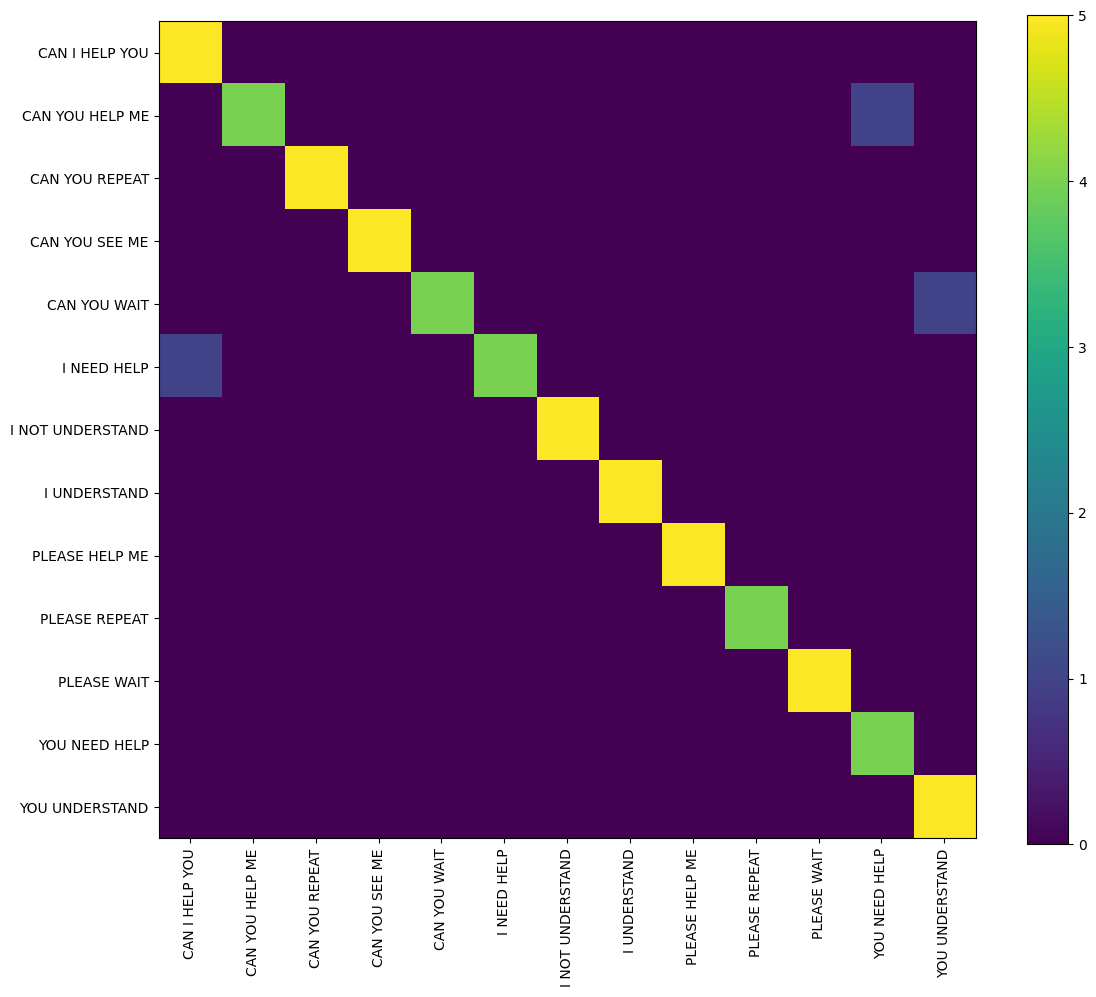

In [39]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    phrases,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    phrases
)

plt.tight_layout()

plt.show()

In [40]:
plt.figure(figsize=(12,10))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(NUM_CLASSES),
    phrases,
    rotation=90
)

plt.yticks(
    range(NUM_CLASSES),
    phrases
)

plt.tight_layout()

plt.savefig(
    f"{SAVE_DIR}/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("saved")

saved


Save Metrics Summary

In [41]:
summary = f"""
Meetix Full Split Results

Accuracy: {acc:.6f}
F1 Macro: {f1_macro:.6f}
F1 Weighted: {f1_weighted:.6f}

Train Accuracy: 0.9966
Validation Accuracy: 0.9219
"""

with open(
    f"{SAVE_DIR}/metrics_summary.txt",
    "w"
) as f:

    f.write(summary)

print(summary)


Meetix Full Split Results

Accuracy: 0.952381
F1 Macro: 0.951826
F1 Weighted: 0.952060

Train Accuracy: 0.9966
Validation Accuracy: 0.9219



In [43]:
import json

with open(
    f"{SAVE_DIR}/phrase_map.json",
    "w"
) as f:
    json.dump(
        phrase_to_id,
        f,
        indent=2
    )

In [44]:
import pandas as pd

pd.DataFrame(history).to_csv(
    f"{SAVE_DIR}/training_history.csv",
    index=False
)